# 🧠 Détection de Tumeurs Cérébrales — Projet Amélioré

**Modèles comparés :**
- DenseNet121 (Transfer Learning)
- Xception (Transfer Learning)
- EfficientNetB0 (Transfer Learning — **corrigé** : preprocessing dédié)
- Random Forest sur features CNN
- ANN sur features CNN

**Améliorations apportées :**
1. ✅ EfficientNetB0 utilise maintenant `preprocess_input` correct (était à 40% → corrigé)
2. ✅ ANN utilise `keras.Input` au lieu de `input_shape` (warning corrigé)
3. ✅ EarlyStopping ajouté sur Xception (manquant)
4. ✅ ModelCheckpoint ajouté pour sauvegarder le meilleur modèle
5. ✅ ReduceLROnPlateau ajouté pour stabiliser l'entraînement
6. ✅ Fine-tuning activé après phase freeze (dégèle des dernières couches)
7. ✅ Sauvegarde au format `.keras` natif (au lieu de `.h5` legacy)
8. ✅ Visualisation des courbes d'entraînement pour chaque modèle
9. ✅ Tableau comparatif final avec graphique
10. ✅ Fonction `predict_single_image` corrigée (chemin Windows portable)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0
GPU disponible: False


---
## 1. Définir les chemins et hyperparamètres
---

In [2]:
train_dir = "brain_tumor_split/train"
val_dir   = "brain_tumor_split/val"
test_dir  = "brain_tumor_split/test"

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 25   # augmenté légèrement
LR         = 1e-4

# Vérification des dossiers
for d in [train_dir, val_dir, test_dir]:
    assert os.path.exists(d), f"❌ Dossier introuvable : {d}"
    print(f"✅ {d}")

✅ brain_tumor_split/train
✅ brain_tumor_split/val
✅ brain_tumor_split/test


---
## 2. Chargement des données (augmentation + générateurs)
---

In [3]:
# Augmentation enrichie pour le train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],   # NOUVEAU : variation de luminosité
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

def make_generator(datagen, directory, shuffle=True):
    return datagen.flow_from_directory(
        directory,
        target_size=(IMG_SIZE, IMG_SIZE),
        color_mode="rgb",
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=shuffle
    )

train_generator = make_generator(train_datagen,    train_dir)
val_generator   = make_generator(val_test_datagen, val_dir)
test_generator  = make_generator(val_test_datagen, test_dir, shuffle=False)

print("\nClasses :", train_generator.class_indices)
print(f"Train : {train_generator.n} images")
print(f"Val   : {val_generator.n} images")
print(f"Test  : {test_generator.n} images")

Found 176 images belonging to 2 classes.
Found 37 images belonging to 2 classes.
Found 40 images belonging to 2 classes.

Classes : {'no': 0, 'yes': 1}
Train : 176 images
Val   : 37 images
Test  : 40 images


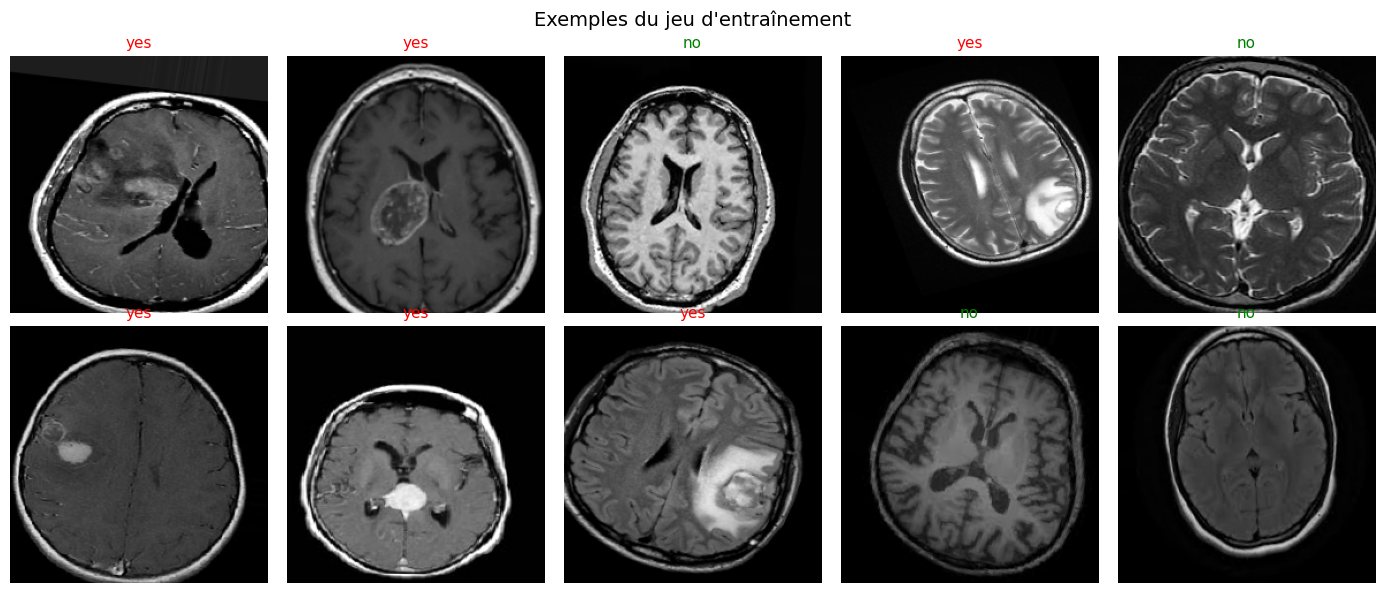

In [4]:
# Visualisation d'un échantillon d'images
images, labels = next(train_generator)
class_names = {v: k for k, v in train_generator.class_indices.items()}

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    ax.set_title(class_names[int(labels[i])], fontsize=11,
                 color='red' if int(labels[i]) == 1 else 'green')
    ax.axis('off')
plt.suptitle("Exemples du jeu d'entraînement", fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Fonctions utilitaires
---

In [5]:
def get_callbacks(model_name, monitor="val_loss"):
    """Retourne les callbacks standards : EarlyStopping + ModelCheckpoint + ReduceLR."""
    return [
        EarlyStopping(
            monitor=monitor, patience=6,
            restore_best_weights=True, verbose=1
        ),
        ModelCheckpoint(
            filepath=f"{model_name}_best.keras",
            monitor=monitor, save_best_only=True, verbose=0
        ),
        ReduceLROnPlateau(
            monitor=monitor, factor=0.5, patience=3,
            min_lr=1e-7, verbose=1
        )
    ]

def build_transfer_model(base_model, model_name):
    """Construit un modèle transfer learning avec tête de classification."""
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation="sigmoid")(x)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=LR),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    print(f"✅ {model_name} créé — {model.count_params():,} paramètres")
    return model

def fine_tune_model(model, base_model, unfreeze_from, model_name):
    """Phase 2 : dégeler les dernières couches pour fine-tuning."""
    base_model.trainable = True
    for layer in base_model.layers[:unfreeze_from]:
        layer.trainable = False
    model.compile(
        optimizer=Adam(learning_rate=LR / 10),   # LR plus faible
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    trainable = sum(1 for l in base_model.layers if l.trainable)
    print(f"🔓 Fine-tuning {model_name} : {trainable} couches dégelées")
    return model

def evaluate_model(model, generator, model_name):
    """Évalue le modèle et retourne (acc, prec, rec, f1, y_pred)."""
    generator.reset()
    y_prob = model.predict(generator, verbose=1)
    y_pred = (y_prob > 0.5).astype(int).reshape(-1)
    y_true = generator.classes

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n===== {model_name} =====")
    print(f"Accuracy : {acc:.4f} | Precision : {prec:.4f} | Recall : {rec:.4f} | F1 : {f1:.4f}")
    print(classification_report(y_true, y_pred,
          target_names=["No Tumor", "Tumor"]))
    return acc, prec, rec, f1, y_pred

def plot_training(history, model_name):
    """Affiche les courbes loss/accuracy d'entraînement."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['loss'],     label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'{model_name} — Loss')
    ax1.legend(); ax1.set_xlabel('Epoch')

    ax2.plot(history.history['accuracy'],     label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title(f'{model_name} — Accuracy')
    ax2.legend(); ax2.set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Tumor", "Tumor"],
                yticklabels=["No Tumor", "Tumor"])
    plt.xlabel("Prédiction"); plt.ylabel("Vraie étiquette")
    plt.title(f"Matrice de Confusion — {model_name}")
    plt.tight_layout(); plt.show()

---
## 4. DenseNet121
---

✅ DenseNet121 créé — 7,168,833 paramètres
Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.5625 - loss: 0.8309 - val_accuracy: 0.5135 - val_loss: 0.7709 - learning_rate: 1.0000e-04
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5852 - loss: 0.7899 - val_accuracy: 0.5135 - val_loss: 0.7251 - learning_rate: 1.0000e-04
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5852 - loss: 0.7586 - val_accuracy: 0.5405 - val_loss: 0.6809 - learning_rate: 1.0000e-04
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6136 - loss: 0.7086 - val_accuracy: 0.6486 - val_loss: 0.6409 - learning_rate: 1.0000e-04
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5966 - loss: 0.6957 - val_accuracy: 0.6486 - val_loss: 0.6044 - learning_rate: 1.0000e-04
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6534 - loss: 0.6749 - val_accuracy: 0.6486 - val_loss: 0.5713 - learning_rate: 1.0000e-04
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step 

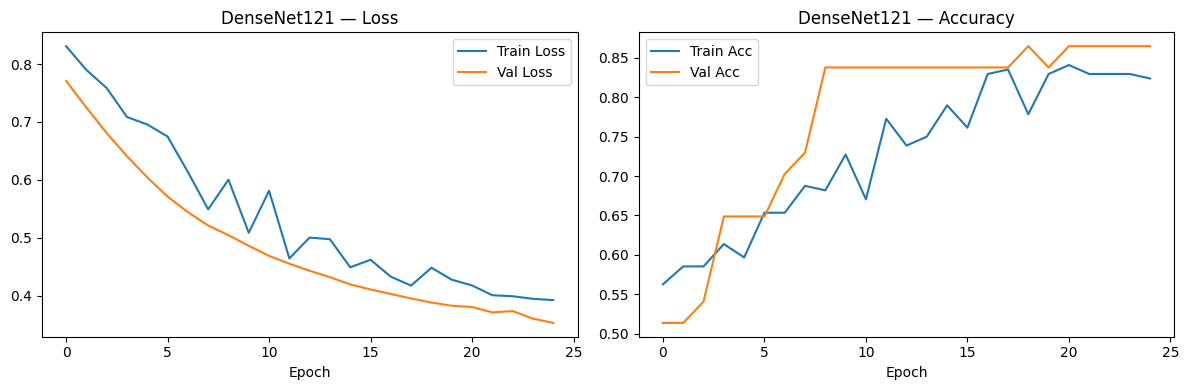

In [6]:
from tensorflow.keras.applications import DenseNet121

densenet_base  = DenseNet121(weights="imagenet", include_top=False,
                              input_shape=(IMG_SIZE, IMG_SIZE, 3))
densenet_model = build_transfer_model(densenet_base, "DenseNet121")

# Phase 1 : entraînement tête seule
history_densenet = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=get_callbacks("densenet")
)
plot_training(history_densenet, "DenseNet121")

🔓 Fine-tuning DenseNet121 : 30 couches dégelées
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.6648 - loss: 0.6606 - val_accuracy: 0.8649 - val_loss: 0.3493 - learning_rate: 1.0000e-05
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6818 - loss: 0.6185 - val_accuracy: 0.8919 - val_loss: 0.3472 - learning_rate: 1.0000e-05
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6989 - loss: 0.6209 - val_accuracy: 0.8919 - val_loss: 0.3465 - learning_rate: 1.0000e-05
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7216 - loss: 0.6406 - val_accuracy: 0.8649 - val_loss: 0.3469 - learning_rate: 1.0000e-05
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7216 - loss: 0.5867 - val_accuracy: 0.9189 - val_loss: 0.3476 - learning_rate: 1.0000e-05
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7856 - loss: 0.4797
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step -

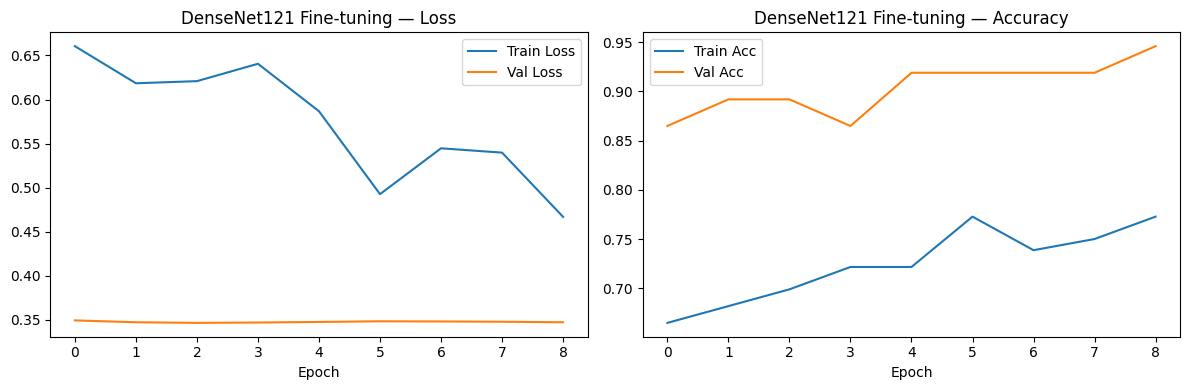

In [7]:
# Phase 2 : Fine-tuning (NOUVEAU)
densenet_model = fine_tune_model(densenet_model, densenet_base,
                                  unfreeze_from=-30, model_name="DenseNet121")
history_densenet_ft = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=get_callbacks("densenet_ft")
)
plot_training(history_densenet_ft, "DenseNet121 Fine-tuning")

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step

===== DenseNet121 =====
Accuracy : 0.8250 | Precision : 0.7931 | Recall : 0.9583 | F1 : 0.8679
              precision    recall  f1-score   support

    No Tumor       0.91      0.62      0.74        16
       Tumor       0.79      0.96      0.87        24

    accuracy                           0.82        40
   macro avg       0.85      0.79      0.80        40
weighted avg       0.84      0.82      0.82        40



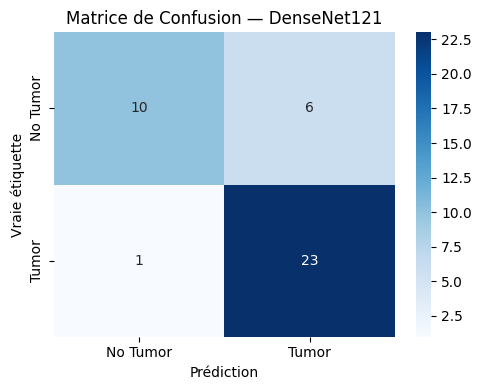

In [8]:
densenet_results = evaluate_model(densenet_model, test_generator, "DenseNet121")
plot_confusion_matrix(test_generator.classes, densenet_results[4], "DenseNet121")

---
## 5. Xception
---

✅ Xception créé — 21,123,881 paramètres
Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5398 - loss: 0.7143 - val_accuracy: 0.6216 - val_loss: 0.6638 - learning_rate: 1.0000e-04
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6080 - loss: 0.6730 - val_accuracy: 0.6216 - val_loss: 0.6090 - learning_rate: 1.0000e-04
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6534 - loss: 0.6190 - val_accuracy: 0.7027 - val_loss: 0.5664 - learning_rate: 1.0000e-04
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6875 - loss: 0.5672 - val_accuracy: 0.7027 - val_loss: 0.5360 - learning_rate: 1.0000e-04
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7614 - loss: 0.5343 - val_accuracy: 0.7297 - val_loss: 0.5062 - learning_rate: 1.0000e-04
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7614 - loss: 0.5227 - val_accuracy: 0.7838 - val_loss: 0.4808 - learning_rate: 1.0000e-04
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - ac

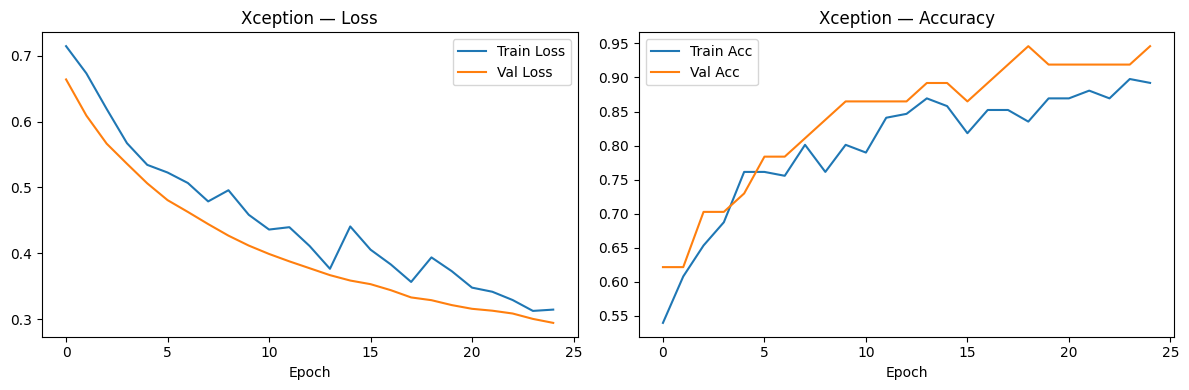

In [9]:
from tensorflow.keras.applications import Xception

xception_base  = Xception(weights="imagenet", include_top=False,
                           input_shape=(IMG_SIZE, IMG_SIZE, 3))
xception_model = build_transfer_model(xception_base, "Xception")

history_xception = xception_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=get_callbacks("xception")   
)
plot_training(history_xception, "Xception")

🔓 Fine-tuning Xception : 20 couches dégelées
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8011 - loss: 0.5236 - val_accuracy: 0.9459 - val_loss: 0.2835 - learning_rate: 1.0000e-05
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8068 - loss: 0.4977 - val_accuracy: 0.9459 - val_loss: 0.2721 - learning_rate: 1.0000e-05
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8636 - loss: 0.4818 - val_accuracy: 0.9459 - val_loss: 0.2618 - learning_rate: 1.0000e-05
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8920 - loss: 0.4478 - val_accuracy: 0.9189 - val_loss: 0.2512 - learning_rate: 1.0000e-05
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8807 - loss: 0.4215 - val_accuracy: 0.9189 - val_loss: 0.2415 - learning_rate: 1.0000e-05
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8466 - loss: 0.4241 - val_accuracy: 0.9189 - val_loss: 0.2350 - learning_rate: 1.0000e-05
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/

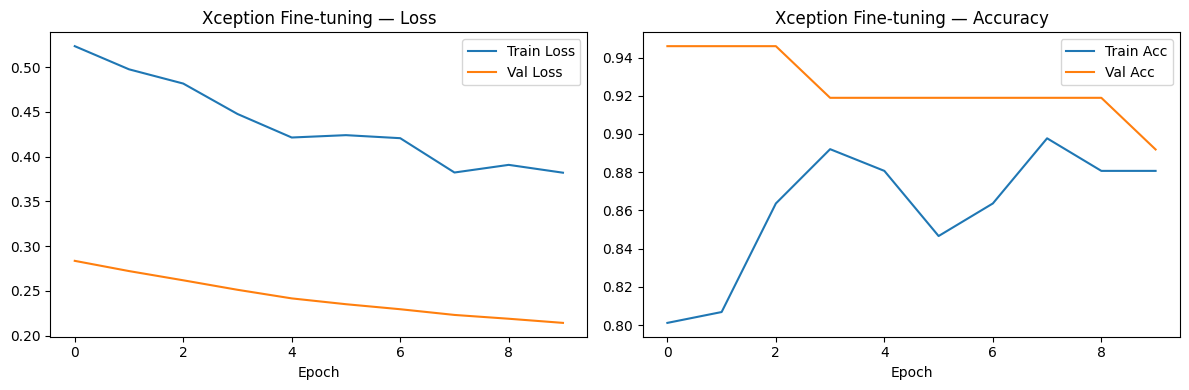

In [10]:
# Fine-tuning Xception
xception_model = fine_tune_model(xception_model, xception_base,
                                  unfreeze_from=-20, model_name="Xception")
history_xception_ft = xception_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=get_callbacks("xception_ft")
)
plot_training(history_xception_ft, "Xception Fine-tuning")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step

===== Xception =====
Accuracy : 0.8500 | Precision : 0.9091 | Recall : 0.8333 | F1 : 0.8696
              precision    recall  f1-score   support

    No Tumor       0.78      0.88      0.82        16
       Tumor       0.91      0.83      0.87        24

    accuracy                           0.85        40
   macro avg       0.84      0.85      0.85        40
weighted avg       0.86      0.85      0.85        40



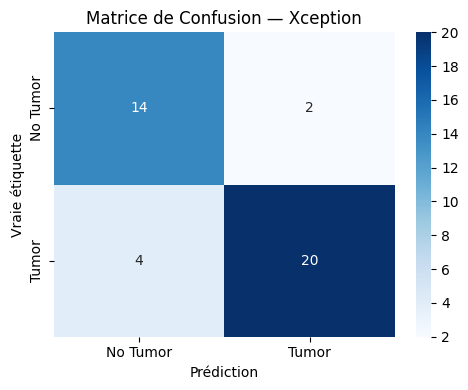

In [11]:
xception_results = evaluate_model(xception_model, test_generator, "Xception")
plot_confusion_matrix(test_generator.classes, xception_results[4], "Xception")

---
## 6. EfficientNetB0 

**Bug original :** EfficientNet avait son propre `preprocess_input` interne mais les données étaient
normalisées manuellement avec `rescale=1/255`, causant un double-preprocessing → accuracy 40% (random).

**Correction :** Utilisation de `preprocess_input` officiel d'EfficientNet (normalise vers [-1, 1]).

---

Found 176 images belonging to 2 classes.
Found 37 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
✅ EfficientNetB0 créé — 4,213,668 paramètres
Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3807 - loss: 0.8375 - val_accuracy: 0.3784 - val_loss: 0.7500 - learning_rate: 1.0000e-04
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 869ms/step - accuracy: 0.5000 - loss: 0.7339 - val_accuracy: 0.5946 - val_loss: 0.6803 - learning_rate: 1.0000e-04
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 874ms/step - accuracy: 0.5909 - loss: 0.6651 - val_accuracy: 0.5946 - val_loss: 0.6506 - learning_rate: 1.0000e-04
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 865ms/step - accuracy: 0.6080 - loss: 0.6544 - val_accuracy: 0.5946 - val_loss: 0.6225 - learning_rate: 1.0000e-04
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 871ms/step - accuracy: 0.6818 - loss: 0.6113 - val_accuracy: 0.6757 - val_loss: 0.5917 - learning_rate: 1.0000e-04
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 857ms/step - accuracy: 0.71

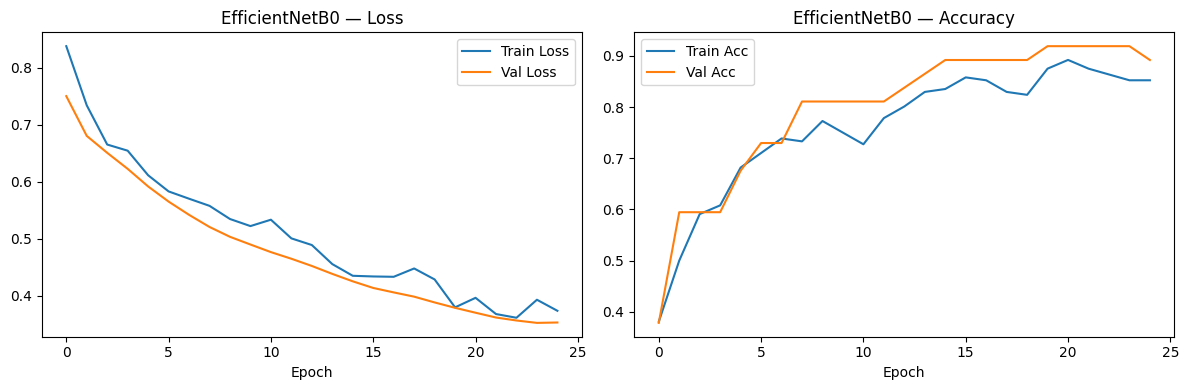

In [12]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

train_datagen_eff = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
val_test_datagen_eff = ImageDataGenerator(preprocessing_function=eff_preprocess)

train_gen_eff = train_datagen_eff.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary"
)
val_gen_eff = val_test_datagen_eff.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary"
)
test_gen_eff = val_test_datagen_eff.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)

efficientnet_base  = EfficientNetB0(weights="imagenet", include_top=False,
                                     input_shape=(IMG_SIZE, IMG_SIZE, 3))
efficientnet_model = build_transfer_model(efficientnet_base, "EfficientNetB0")

history_efficientnet = efficientnet_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=EPOCHS,
    callbacks=get_callbacks("efficientnet")
)
plot_training(history_efficientnet, "EfficientNetB0")

🔓 Fine-tuning EfficientNetB0 : 20 couches dégelées
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7159 - loss: 0.5664 - val_accuracy: 0.9189 - val_loss: 0.3462 - learning_rate: 1.0000e-05
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 936ms/step - accuracy: 0.8239 - loss: 0.5309 - val_accuracy: 0.9189 - val_loss: 0.3416 - learning_rate: 1.0000e-05
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 940ms/step - accuracy: 0.6932 - loss: 0.5710 - val_accuracy: 0.9189 - val_loss: 0.3377 - learning_rate: 1.0000e-05
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 941ms/step - accuracy: 0.7216 - loss: 0.5663 - val_accuracy: 0.9189 - val_loss: 0.3356 - learning_rate: 1.0000e-05
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 946ms/step - accuracy: 0.7216 - loss: 0.5527 - val_accuracy: 0.9459 - val_loss: 0.3346 - learning_rate: 1.0000e-05
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 946ms/step - accuracy: 0.7955 - loss: 0.5160 - val_accuracy: 0.9459 - val_loss: 0.3344 - learning_rate: 1.0000e-05
Epoch 7/10
6/6 ━━━━━━━━━━━━

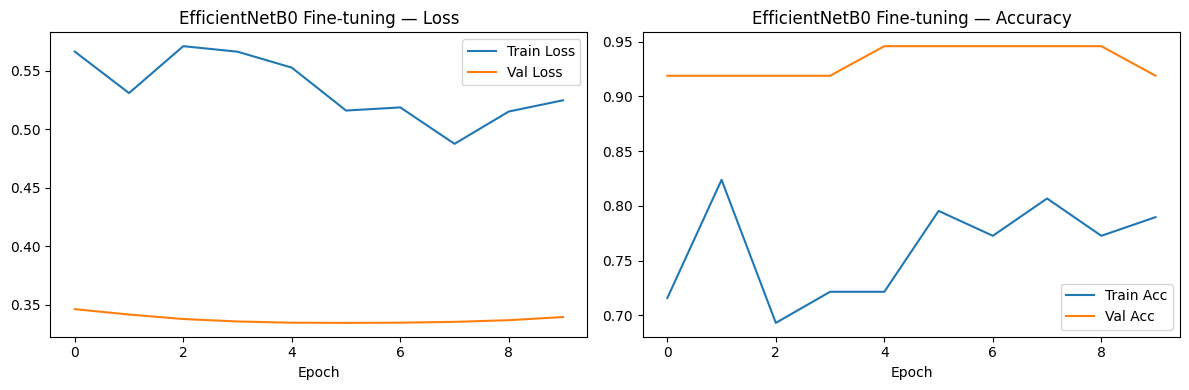

In [13]:
# Fine-tuning EfficientNet
efficientnet_model = fine_tune_model(efficientnet_model, efficientnet_base,
                                      unfreeze_from=-20, model_name="EfficientNetB0")
history_eff_ft = efficientnet_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=10,
    callbacks=get_callbacks("efficientnet_ft")
)
plot_training(history_eff_ft, "EfficientNetB0 Fine-tuning")

1/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001EDDDE98400> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step

===== EfficientNetB0 =====
Accuracy : 0.9000 | Precision : 0.9167 | Recall : 0.9167 | F1 : 0.9167
              precision    recall  f1-score   support

    No Tumor       0.88      0.88      0.88      

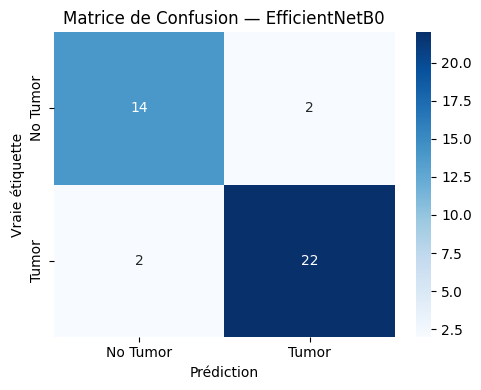

In [14]:
efficientnet_results = evaluate_model(efficientnet_model, test_gen_eff, "EfficientNetB0")
plot_confusion_matrix(test_gen_eff.classes, efficientnet_results[4], "EfficientNetB0")

---
## 7. Random Forest — sur features CNN (DenseNet)
---

In [15]:
# Extracteur de features via DenseNet pré-entraîné
feature_extractor = DenseNet121(
    weights="imagenet", include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling="avg"
)
feature_extractor.trainable = False

# Générateurs sans augmentation pour extraction des features
train_gen_feat = val_test_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)
test_gen_feat = val_test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)

print("Extraction des features d'entraînement...")
train_features = feature_extractor.predict(train_gen_feat, verbose=1)
y_train_feat   = train_gen_feat.classes

print("Extraction des features de test...")
test_features = feature_extractor.predict(test_gen_feat, verbose=1)
y_test_feat   = test_gen_feat.classes

print(f"\nShape features train : {train_features.shape}")
print(f"Shape features test  : {test_features.shape}")

Found 176 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
Extraction des features d'entraînement...
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
Extraction des features de test...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 300ms/step

Shape features train : (176, 1024)
Shape features test  : (40, 1024)


===== Random Forest + DenseNet Features =====
              precision    recall  f1-score   support

    No Tumor       0.93      0.81      0.87        16
       Tumor       0.88      0.96      0.92        24

    accuracy                           0.90        40
   macro avg       0.91      0.89      0.89        40
weighted avg       0.90      0.90      0.90        40



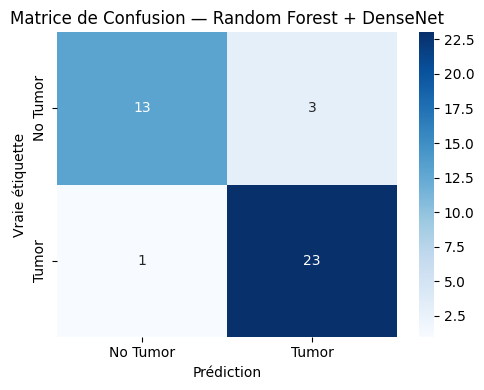

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",    # meilleure généralisation
    random_state=42,
    n_jobs=-1               # parallélisation
)
rf_model.fit(train_features, y_train_feat)

y_pred_rf = rf_model.predict(test_features)

rf_acc  = accuracy_score(y_test_feat, y_pred_rf)
rf_prec = precision_score(y_test_feat, y_pred_rf, zero_division=0)
rf_rec  = recall_score(y_test_feat, y_pred_rf, zero_division=0)
rf_f1   = f1_score(y_test_feat, y_pred_rf, zero_division=0)

print("===== Random Forest + DenseNet Features =====")
print(classification_report(y_test_feat, y_pred_rf,
      target_names=["No Tumor", "Tumor"]))
plot_confusion_matrix(y_test_feat, y_pred_rf, "Random Forest + DenseNet")

---
## 8. ANN sur features CNN 

**Bug original :** Utilisation de `input_shape` déprécié dans `Dense` → UserWarning.

**Correction :** Utilisation de `keras.Input(shape=...)` comme première couche.

---

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,617 (1.16 MB)

 Trainable params: 303,617 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5071 - loss: 0.7844 - val_accuracy: 0.4722 - val_loss: 0.7300 - learning_rate: 1.0000e-04
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6143 - loss: 0.7270 - val_accuracy: 0.8056 - val_loss: 0.5971 - learning_rate: 1.0000e-04
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5500 - loss: 0.7879 - val_accuracy: 0.9167 - val_loss: 0.5228 - learning_rate: 1.0000e-04
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5429 - loss: 0.7730 - val_accuracy: 0.8611 - val_loss: 0.5511 - learning_rate: 1.0000e-04
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5071 - loss: 0.7873 - val_accuracy: 0.8333 - val_loss: 0.5426 - learning_rate: 1.0000e-04
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5286 - loss: 0.6992 - val_accuracy: 0.8056 - val_loss: 0.5754 - learning_rate: 1.0000e-04
Epoch 7/30
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4375 - loss: 0.7713

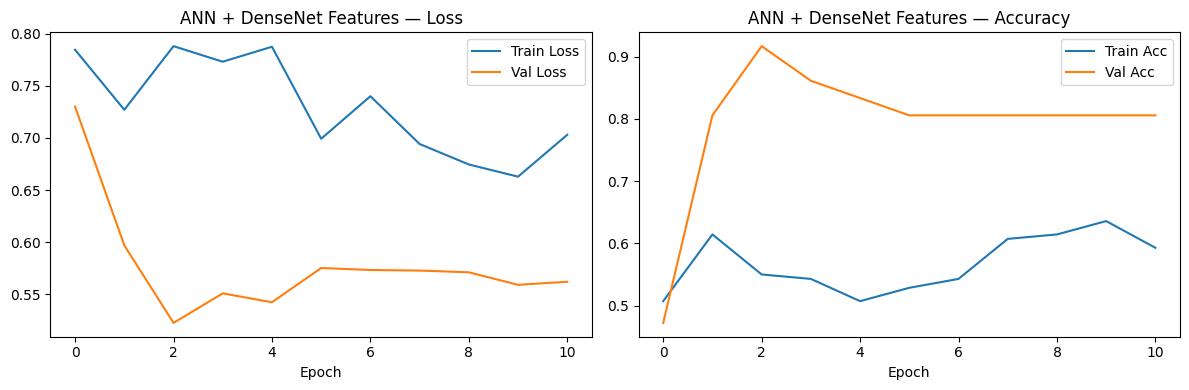

In [17]:
# ✅ CORRIGÉ : keras.Input() au lieu de input_shape dans Dense
ann_model = Sequential([
    Input(shape=(train_features.shape[1],)),    # ← correction ici
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),               # couche supplémentaire
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer=Adam(learning_rate=LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
ann_model.summary()

history_ann = ann_model.fit(
    train_features, y_train_feat,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=4, verbose=1)
    ]
)

plot_training(history_ann, "ANN + DenseNet Features")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
===== ANN + DenseNet Features =====
              precision    recall  f1-score   support

    No Tumor       0.78      0.44      0.56        16
       Tumor       0.71      0.92      0.80        24

    accuracy                           0.72        40
   macro avg       0.74      0.68      0.68        40
weighted avg       0.74      0.72      0.70        40



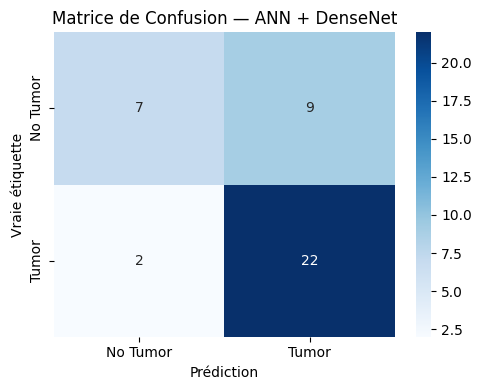

In [18]:
y_pred_ann_prob = ann_model.predict(test_features)
y_pred_ann      = (y_pred_ann_prob > 0.5).astype(int).reshape(-1)

ann_acc  = accuracy_score(y_test_feat, y_pred_ann)
ann_prec = precision_score(y_test_feat, y_pred_ann, zero_division=0)
ann_rec  = recall_score(y_test_feat, y_pred_ann, zero_division=0)
ann_f1   = f1_score(y_test_feat, y_pred_ann, zero_division=0)

print("===== ANN + DenseNet Features =====")
print(classification_report(y_test_feat, y_pred_ann,
      target_names=["No Tumor", "Tumor"]))
plot_confusion_matrix(y_test_feat, y_pred_ann, "ANN + DenseNet")

---
## 9. Comparaison finale des modèles
---

In [19]:
results = pd.DataFrame({
    "Modèle": [
        "DenseNet121",
        "Xception",
        "EfficientNetB0",
        "Random Forest + DenseNet",
        "ANN + DenseNet"
    ],
    "Accuracy":  [densenet_results[0], xception_results[0], efficientnet_results[0], rf_acc,  ann_acc],
    "Precision": [densenet_results[1], xception_results[1], efficientnet_results[1], rf_prec, ann_prec],
    "Recall":    [densenet_results[2], xception_results[2], efficientnet_results[2], rf_rec,  ann_rec],
    "F1-score":  [densenet_results[3], xception_results[3], efficientnet_results[3], rf_f1,   ann_f1]
})

results_sorted = results.sort_values("F1-score", ascending=False).reset_index(drop=True)
print(results_sorted.to_string(index=False))

                  Modèle  Accuracy  Precision   Recall  F1-score
Random Forest + DenseNet     0.900   0.884615 0.958333  0.920000
          EfficientNetB0     0.900   0.916667 0.916667  0.916667
                Xception     0.850   0.909091 0.833333  0.869565
             DenseNet121     0.825   0.793103 0.958333  0.867925
          ANN + DenseNet     0.725   0.709677 0.916667  0.800000


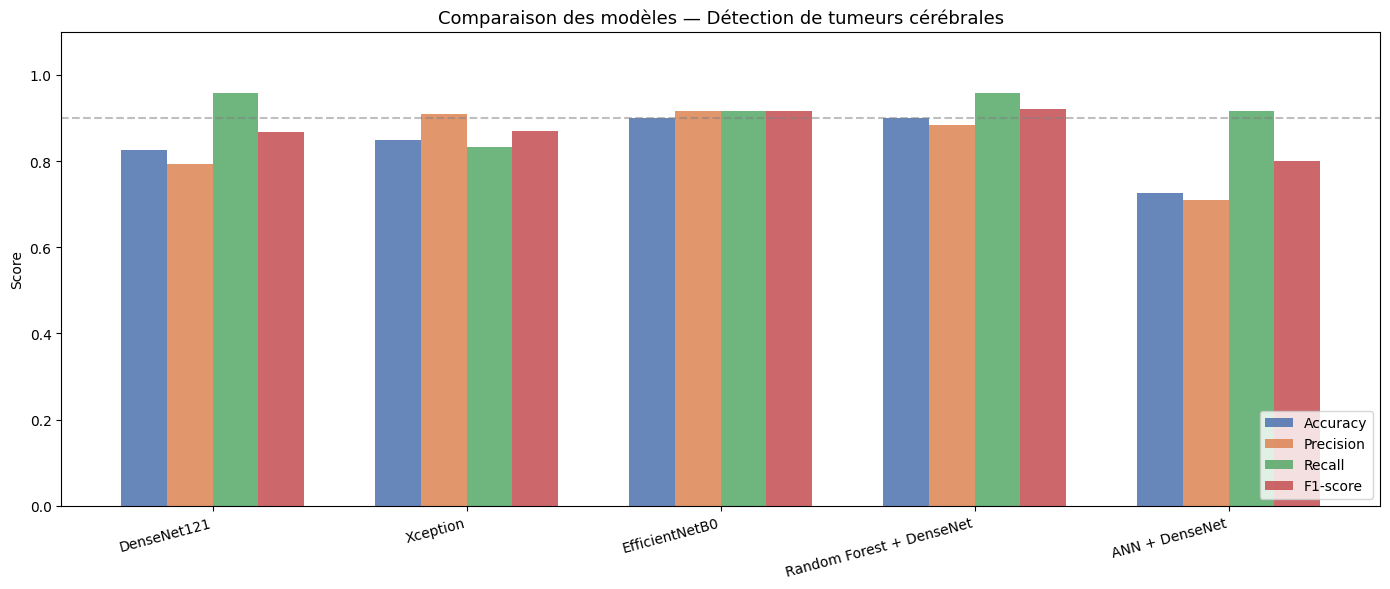

In [41]:
# Graphique comparatif
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(results))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results["Modèle"], rotation=15, ha="right", fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Comparaison des modèles — Détection de tumeurs cérébrales", fontsize=13)
ax.legend(loc="lower right")
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='Seuil 90%')
plt.tight_layout()
plt.show()
densenet_model.save("densenet_brain_tumor.h5")

---
## 10. Sauvegarde des modèles — ✅ Format `.keras` natif
---

In [42]:
import joblib

# ✅ Format .keras natif (au lieu de .h5 legacy)
densenet_model.save("densenet_brain_tumor.keras")
xception_model.save("xception_brain_tumor.keras")
efficientnet_model.save("efficientnet_brain_tumor.keras")
ann_model.save("ann_brain_tumor.keras")

# Random Forest : joblib (inchangé)
joblib.dump(rf_model, "random_forest_brain_tumor.pkl")

print("✅ Tous les modèles sauvegardés avec succès !")

# Compatibilité : garder aussi .h5 si nécessaire
# densenet_model.save("densenet_brain_tumor.h5")

✅ Tous les modèles sauvegardés avec succès !


---
## 11. Prédiction sur une image 
---

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


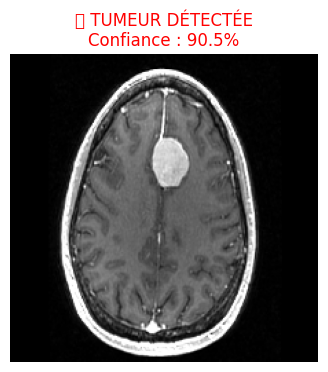

Probabilité brute : 0.9049
Résultat          : 🔴 TUMEUR DÉTECTÉE (confiance : 90.5%)


np.float32(0.90489376)

In [43]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_single_image(model, img_path, img_size=224,
                          preprocess_fn=None, show_image=True):
    """
    Prédit si une image contient une tumeur.
    
    Args:
        model        : modèle Keras chargé
        img_path     : chemin vers l'image
        img_size     : taille d'entrée (défaut 224)
        preprocess_fn: fonction de preprocessing (None = rescale 1/255)
        show_image   : afficher l'image (défaut True)
    """
    if not os.path.exists(img_path):
        print(f"❌ Image introuvable : {img_path}")
        return None

    img       = keras_image.load_img(img_path, target_size=(img_size, img_size))
    img_array = keras_image.img_to_array(img)

    if preprocess_fn:
        img_array = preprocess_fn(img_array)
    else:
        img_array = img_array / 255.0

    img_batch = np.expand_dims(img_array, axis=0)
    prob      = model.predict(img_batch, verbose=0)[0][0]
    label     = "🔴 TUMEUR DÉTECTÉE" if prob > 0.5 else "🟢 Pas de tumeur"
    confidence = prob if prob > 0.5 else (1 - prob)

    if show_image:
        plt.figure(figsize=(4, 4))
        plt.imshow(keras_image.load_img(img_path, target_size=(img_size, img_size)))
        plt.title(f"{label}\nConfiance : {confidence:.1%}", fontsize=12,
                  color='red' if prob > 0.5 else 'green')
        plt.axis('off')
        plt.show()

    print(f"Probabilité brute : {prob:.4f}")
    print(f"Résultat          : {label} (confiance : {confidence:.1%})")
    return prob


# --- Exemple d'utilisation ---
# ✅ CORRIGÉ : utiliser os.path.join pour portabilité (marche sur Windows et Linux)
img_path = os.path.join("brain_tumor_split", "test", "yes", r"c:\Users\Lenovo\Desktop\tests\big_5b252c1a32b7d.jpg")
predict_single_image(xception_model, img_path)

# Pour EfficientNet (preprocessing différent) :
# from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
# predict_single_image(efficientnet_model, img_path, preprocess_fn=eff_pre)